## Sentiment Analysis

Can we trust the review scores as indicators of customer sentiment toward the product?

To answer this question, a sentiment analysis is performed on the reviews, in order to understand the overall sentiment of the reviews and how it relates to the products and users. The sentiment analysis is performed using a pre-trained BERT model fine-tuned on the food reviews dataset. The model is then evaluated on a test set of 300 reviews, and the results are compared to the true labels.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
 
from transformers import pipeline, AutoTokenizer, AutoModel
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import plotly.express as px
import plotly.graph_objects as go
import torch
from pathlib import Path

c:\Users\elena\OneDrive\Desktop\UNI\DA\food-reviews-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
DATA_DIR  = Path('../data/processed')
MODEL_DIR = Path('../src/models/bert-reviews-tuned')

INT_TO_NAME  = {0: 'negative', 1: 'neutral', 2: 'positive'}
PALETTE      = {'negative': '#e05c5c', 'neutral': '#f0a500', 'positive': '#4caf82'}

### Model Evaluation on Test Set

Before using the model for business insights, we qualify its reliability.
The test set was held out during fine-tuning and never seen by the model.

In [ ]:
test_df = pd.read_csv(DATA_DIR / "test_data.csv").sample(frac=1, random_state=42).head(300)
model = pipeline("sentiment-analysis", model="../src/models/bert-reviews-tuned", tokenizer="../src/models/bert-reviews-tuned", truncation=True)
LABEL_MAP = {
    'LABEL_0': 0,
    'LABEL_1': 1,
    'LABEL_2': 2
}

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2895.45it/s]


In [ ]:
TEST_RESULTS = DATA_DIR / 'test_results.csv'
 
if TEST_RESULTS.exists():
    test_df = pd.read_csv(TEST_RESULTS)
    print(f'Loaded existing results.')
else:
    raw_test = pd.read_csv(DATA_DIR / 'test_data.csv').sample(frac=1, random_state=42).head(300)
    model_pipe = pipeline('sentiment-analysis',
        model=str(MODEL_DIR), tokenizer=str(MODEL_DIR),
        truncation=True, device=0 if torch.cuda.is_available() else -1
    )
    results = model_pipe(raw_test['text'].tolist(), batch_size=32)
    raw_test['pred_label'] = [LABEL_MAP[r['label']] for r in results]
    raw_test.to_csv(TEST_RESULTS, index=False)
    test_df = raw_test

Loaded existing test results (300 rows).


In [5]:
if test_df['pred_label'].dtype == object:
    test_df['pred_label'] = test_df['pred_label'].map(LABEL_MAP)

y_true = test_df['label'].astype(int)
y_pred = test_df['pred_label'].astype(int)

CLASS_ORDER  = ['negative', 'neutral', 'positive']

In [ ]:
print(f"Accuracy:        {accuracy_score(y_true, y_pred):.3f}")
print(f"Macro Precision: {precision_score(y_true, y_pred, average='macro'):.3f}")
print(f"Macro Recall:    {recall_score(y_true, y_pred, average='macro'):.3f}")
print(f"Macro F1:        {f1_score(y_true, y_pred, average='macro'):.3f}")
print()
print(classification_report(y_true, y_pred, target_names=CLASS_ORDER))

Accuracy:        0.863
Macro Precision: 0.656
Macro Recall:    0.621
Macro F1:        0.629

              precision    recall  f1-score   support

    negative       0.72      0.74      0.73        42
     neutral       0.33      0.17      0.22        24
    positive       0.91      0.96      0.94       234

    accuracy                           0.86       300
   macro avg       0.66      0.62      0.63       300
weighted avg       0.84      0.86      0.85       300



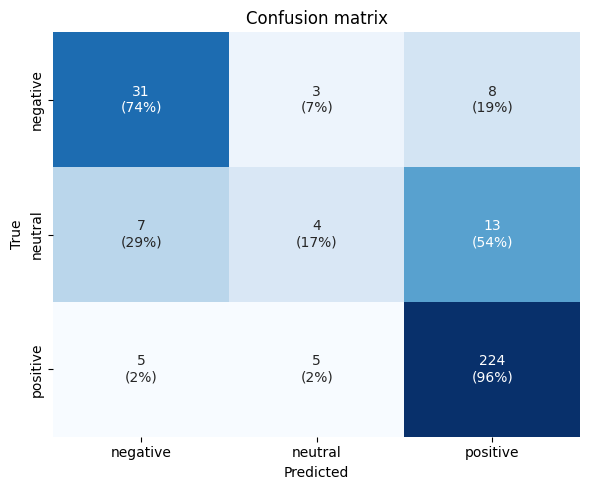

In [ ]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
 
labels = np.array([
    [f'{cm[i,j]}\n({cm_norm[i,j]:.0%})' for j in range(3)]
    for i in range(3)
])
 
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_norm, annot=labels, fmt='', cmap='Blues', xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, cbar=False)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion matrix')
plt.tight_layout()
plt.show()

## Agreement between score and BERT predictions

The central question is: when do numeric scores and predicted sentiment tell the same story and when don't they?

In [9]:
test_df['agree'] = test_df['label'] == test_df['pred_label']
rate = test_df['agree'].mean()
 
print(f'''Agreement rate (accuracy): {rate:.1%}
Matching: {test_df["agree"].sum()}
Diverging: {(~test_df["agree"]).sum()}''')

Agreement rate (accuracy): 86.3%
Matching: 259
Diverging: 41


As we can see in the confusion matrix, the agreement per class is:
- positive: 96%
- neutral: 17%
- negative: 74%

This indicates that the model performs very well in identifying positive reviews, likely due to the large number of positive examples in the dataset. It has difficulty with neutral reviews, which is understandable since neutral reviews tend to be ambiguous and open to multiple interpretations. The model is also good at predicting negative reviews, but it is not as good as it is for positive reviews.

In [17]:
misclassified = test_df[test_df['label'] != test_df['pred_label']]
misclassified.to_csv(DATA_DIR / 'misclassified.csv', index=False)

Afterwards, an analysis was conducted on a sample of the misclassified reviews to identify the primary causes of the errors. A quick inspection suggests that the model misclassifies mainly reviews that are not clearly positive or negative, but rather neutral or mixed in sentiment.  
The most misclassified reviews are the neutral ones, which often contain mixed opinions and are challenging to classify even for humans. Additionally, the model incorrectly classifies some positive and negative reviews for various reasons. Some distinct cases can be identified:  

#### 1. BERT's structural limits
Clear errors by the model include handling too long reviews that get truncated, texts covering multiple topics or products, and mixed opinions that include strong words not representative of the overall sentiment.

examples:  
"This tea smells wonderful but I think it needs to be made very strong to get the taste.It helps to add some sweetener. It was not as rich in taste as I had hoped for."  
true label: 1 - predicted label: 2  

"A dill pickle should have just what this pickle has, good flavor and great crunch. It's for adults, though. When one of the younger kids tried it, he pronounced the flavor to be 'disgusting'."  
true label: 2 - predicted label: 0  
  
  
#### 2. Inaccurate score 
In some cases, the actual score assigned is not entirely accurate, and BERT's interpretation better reflects the sentiment expressed than the user's given rating.

examples:  
"They are great treats but my dogs were never interested in spending time trying to get food out of something. They do play with the toy that is suggested to use with the treats, but just as a ball. There was nothing wrong with the product, just not a good choice for my dogs, and very expensive to use just as treats, which we did."  
true label: 0 - predicted label: 1  

"So i got this here turkish delight box. These are in my opinion a step away from your average turkish delight (not that i am a seasoned T.D.consumer) but they are more than anything just too soft...just like winegum even though they are much easier to chew up if you will, and therefore reminiscent of eating plain candy even though they have a very good quality consitency and taste. These come largely without any nuts inside..maybe the odd bite though. But the sugar coating is excessive and may upset your tummy. Don`t eat to many of these at any one time. YE BE WARNED! I think i would try to open them up and maybe let them sit a few days to become dry?? (more chewing resistance) Even maybe try to get wrid of some of that sugar coating?! Anyway i like the way the box opens. Side opening with a nice drawout feature and neatly wrapped in a thin plastic foil. So basically these come plain, with the odd bite with some nuts inside. Not my favourite. Too little fibre maybe?"  
true label: 2 - predicted label: 1  
  
  
#### 3. Reason behind the score
User ratings are often heavily influenced by factors unrelated to the product itself, such as delivery, packaging, or other external elements.

examples:  
"I bought this product for a coctail party. When it arrived most of the crackers were chipped or completely unusable to serve to guests. I bought 2 boxes so it turned into a $25.00 mid-night snack. If you have the opportunity to buy them in the grocery do so, they taste great."  
true label: 0 - predicted label: 2

"I ordered 12 steaks but only six arrived. I contacted Omaha and they said they would send six more. When the six more arrived they were completely thawed and now I am afraid to eat them -- maybe I will fry them up and give them to my dog -- he has a strong stomach. The six that arrived on time and still frozen were delicious. If this were baseball I would be thrilled, but I am not happy batting .500 in the steak department. Update: Omaha sent me 12 more steaks. They arrived still frozen and the two I have eaten were delicious. So all told, I originally ordered 12 -- only six arrived -- six more were sent but were thawed -- but then they sent 12 and they were great. So in the end I ordered 12, but got 18 great steaks. Omaha made it more than right. Omaha may not be good at counting but they get an A for effort"  
true label: 0 - predicted label: 2

It is important to note that many such reviews might not be misclassified by BERT, yet they still do not accurately represent the overall sentiment toward the product. To gain deeper insights, we need to understand the reasons behind the model's classifications. We will explore this using model explainability techniques in the next section.

### Embedding Visualization

Finally, we create simple visualizations of the reviews in a 2D space, using PCA and T-SNE. The embeddings are obtained from the BERT model, and they are used to understand the distribution of the reviews in the embedding space. The visualization is interactive, and it allows to explore the reviews and their sentiment.

In [22]:
EMB_FILE = DATA_DIR / 'cls_embeddings.csv'

if EMB_FILE.exists():
    emb_df         = pd.read_csv(EMB_FILE)
    cls_labels     = emb_df['label'].tolist()
    cls_embeddings = emb_df.drop(columns='label').values
    print(f'Loaded embeddings')
else:
    tokenizer  = AutoTokenizer.from_pretrained(str(MODEL_DIR))
    bert_model = AutoModel.from_pretrained(str(MODEL_DIR))

    sentences = test_df['text'].tolist()
    input_ids = tokenizer(sentences, return_tensors='pt', padding=True,
                          truncation=True, max_length=128)
    with torch.no_grad():
        output_sent = bert_model(**input_ids)

    cls_embeddings = output_sent.last_hidden_state[:, 0, :].numpy()
    cls_labels = [
        f"{INT_TO_NAME[row.pred_label]} - {row.text[:80]}…"
        for row in test_df.itertuples()
    ]

    emb_df = pd.DataFrame(cls_embeddings)
    emb_df['label'] = cls_labels
    emb_df.to_csv(EMB_FILE, index=False)
    print(f'Saved embeddings')


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1618.40it/s]
[transformers] BertModel LOAD REPORT from: ..\src\models\bert-reviews-tuned
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Saved embeddings


In [ ]:
# wordviz: custom library for embedding visualization (pip install wordviz)
from wordviz.loading import EmbeddingLoader
from wordviz.plotting import Visualizer

loader = EmbeddingLoader()
loader.load_contextual(embeddings=cls_embeddings, labels=cls_labels,embedding_type='sentence')
viz = Visualizer(loader)

fig = viz.plot_interactive(red_method='pca', theme='light1', title='Reviews BERT embeddings')
fig.show()

Contextual embedding loaded


In [26]:
fig2 = viz.plot_interactive(red_method='tsne', theme='light1', title='Reviews BERT embeddings T-SNE')
fig2.show()

In both visualizations, the reviews are grouped based on their sentiment, with positive reviews on one side, negative reviews on the opposite side, and neutral reviews positioned in the middle, all situated near each other.

In the following sections, we will explore the reasons behind the model's classifications using model explainability techniques. This way, we will also discover the main reasons behind the good or bad reviews, and how they relate to the products.